# 🏦 Predicción de Bajas de Clientes Bancarios
### Proyecto Final de Machine Learning

---

| | |
|---|---|
| **Dataset** | Bank Customer Churn — 10.000 clientes europeos |
| **Problema** | Clasificación binaria supervisada |
| **Objetivo** | Predecir si un cliente abandonará el banco (`Exited = 1`) |
| **Métrica principal** | ROC-AUC |
| **Modelo final** | XGBoost optimizado |
| **Autores** | [Nombre 1] · [Nombre 2] · [Nombre 3] |

---

## 📋 Índice

1. [Importación de librerías](#paso1)
2. [Carga y exploración inicial](#paso2)
3. [División Train / Test](#paso3)
4. [Análisis del target](#paso4)
5. [EDA univariante](#paso5)
6. [EDA bivariante](#paso6)
7. [Eliminación de features](#paso7)
8. [Duplicados](#paso8)
9. [Missings](#paso9)
10. [Outliers](#paso10)
11. [Feature Engineering](#paso11)
12. [Selección de métrica](#paso12)
13. [Modelado — Baseline y comparativa](#paso13)
14. [Optimización de hiperparámetros](#paso14)
15. [Evaluación final sobre test](#paso15)
16. [Persistencia del modelo](#paso16)

<a id="paso1"></a>
## Paso 1 — Importación de Librerías

Importamos todas las librerías necesarias para el proyecto.
Las agrupamos por categoría para facilitar la lectura y el mantenimiento del código.

In [22]:
# Manipulación de datos
import pandas as pd
import numpy as np
pd.options.mode.copy_on_write = True

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y preprocesado
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.metrics import make_scorer

# Persistencia
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración global
sns.set_style('whitegrid')
SEED = 42
print(' Librerías importadas correctamente')

 Librerías importadas correctamente


<a id="paso2"></a>
## Paso 2 — Carga y Exploración Inicial de Datos

Cargamos el dataset y realizamos una primera exploración para entender
su estructura, tipos de variables y estadísticas básicas antes de cualquier transformación.

In [23]:
df = pd.read_csv('src/data_sample/churn.csv')
print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 10,000 filas × 14 columnas


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [24]:
df.info()
print()
print('Estadísticas descriptivas:')
df.describe().T.round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


### Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `RowNumber` | Identificador | Número de fila — **eliminar** |
| `CustomerId` | Identificador | ID único del cliente — **eliminar** |
| `Surname` | Identificador | Apellido del cliente — **eliminar** |
| `CreditScore` | Numérica | Puntuación crediticia |
| `Geography` | Categórica | País (France, Germany, Spain) |
| `Gender` | Categórica | Género del cliente |
| `Age` | Numérica | Edad del cliente |
| `Tenure` | Numérica | Años como cliente del banco |
| `Balance` | Numérica | Saldo en cuenta (USD) |
| `NumOfProducts` | Numérica | Nº de productos bancarios contratados |
| `HasCrCard` | Binaria | Tiene tarjeta de crédito (1=Sí, 0=No) |
| `IsActiveMember` | Binaria | Es miembro activo (1=Sí, 0=No) |
| `EstimatedSalary` | Numérica | Salario estimado anual (USD) |
| `Exited` | **TARGET** | 1 = abandona el banco · 0 = permanece |

> Las columnas `RowNumber`, `CustomerId` y `Surname` son identificadores sin ningún valor
> predictivo — se eliminan antes del split para que el modelo no aprenda atajos artificiales.

In [25]:
# Eliminamos los identificadores antes del split
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

X = df.drop('Exited', axis=1)
y = df['Exited']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols  = X.select_dtypes(include='object').columns.tolist()

print(f'Variables numéricas ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')
print(f'Target: Exited')

Variables numéricas (8): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Variables categóricas (2): ['Geography', 'Gender']
Target: Exited


<a id="paso3"></a>
## Paso 3 — División Train / Test

Este es el paso más crítico del pipeline. Separamos los datos **antes de cualquier
transformación** para garantizar que el modelo nunca ve información del test durante
el entrenamiento.

Usamos `stratify=y` para mantener la misma proporción de clases (80/20) en ambos conjuntos.
A partir de aquí, todos los estadísticos — medianas, percentiles, media del scaler —
se calculan **exclusivamente sobre train** y se aplican igual en test.
Si no, el modelo vería información del futuro — lo que se conoce como **data leakage**.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y)

print(f'Train: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros')
print(f'\nProporción churn — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')
print('→ Proporciones iguales gracias a stratify=y ')
print()
print('  El conjunto de test queda guardado y no se volverá a tocar hasta el Paso 15.')

Train: 8,000 registros | Test: 2,000 registros

Proporción churn — Train: 20.4% | Test: 20.3%
→ Proporciones iguales gracias a stratify=y 

  El conjunto de test queda guardado y no se volverá a tocar hasta el Paso 15.


<a id="paso4"></a>
## Paso 4 — Análisis de la Variable Objetivo

Analizamos la distribución del target para entender el grado de desbalanceo
entre clases y decidir la estrategia de modelado más adecuada.

Distribución del target en TRAIN:
Exited
0    6370
1    1630
Name: count, dtype: int64

Exited
0    79.6%
1    20.4%
Name: proportion, dtype: object


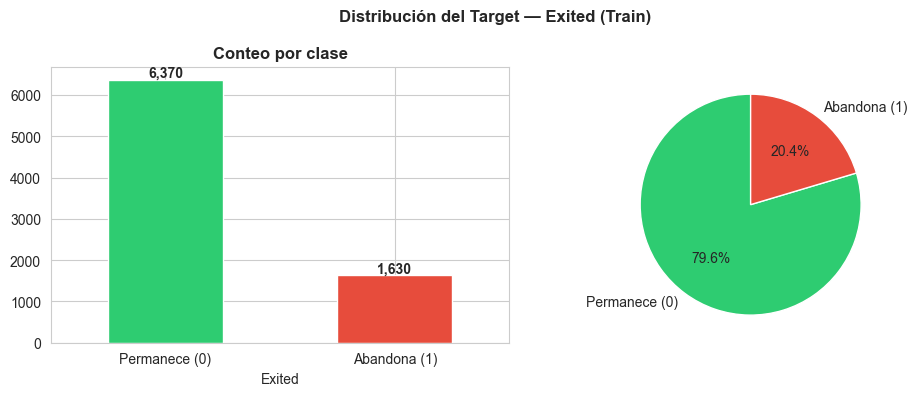

In [27]:
print('Distribución del target en TRAIN:')
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras
y_train.value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='white', rot=0)
axes[0].set_title('Conteo por clase', fontweight='bold')
axes[0].set_xticklabels(['Permanece (0)', 'Abandona (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontweight='bold')

# Gráfico de tarta
y_train.value_counts().plot(kind='pie', ax=axes[1],
    labels=['Permanece (0)', 'Abandona (1)'],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_ylabel('')

plt.suptitle('Distribución del Target — Exited (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusiones del análisis del target

El dataset presenta un **desbalanceo de aproximadamente 80/20**:
hay cuatro veces más clientes que permanecen que clientes que abandonan.

Esto condiciona todas las decisiones técnicas tomadas a partir de aquí:

| Decisión | Motivo |
|---|---|
| **ROC-AUC** como métrica principal | Con 80% de clase mayoritaria, la accuracy es engañosa — un modelo que prediga siempre "permanece" tendría 80% sin aprender nada |
| `class_weight='balanced'` en los modelos | Sin compensación, el modelo ignoraría la clase minoritaria — los churners |
| `stratify=y` en el split | Garantiza la misma proporción 80/20 en train y test |
| `scale_pos_weight` en XGBoost | Parámetro nativo que pondera la clase minoritaria automáticamente |

<a id="paso5"></a>
## Paso 5 — EDA Univariante

Analizamos la distribución individual de cada variable para detectar
outliers, asimetrías y patrones que guíen las decisiones de preprocesado.

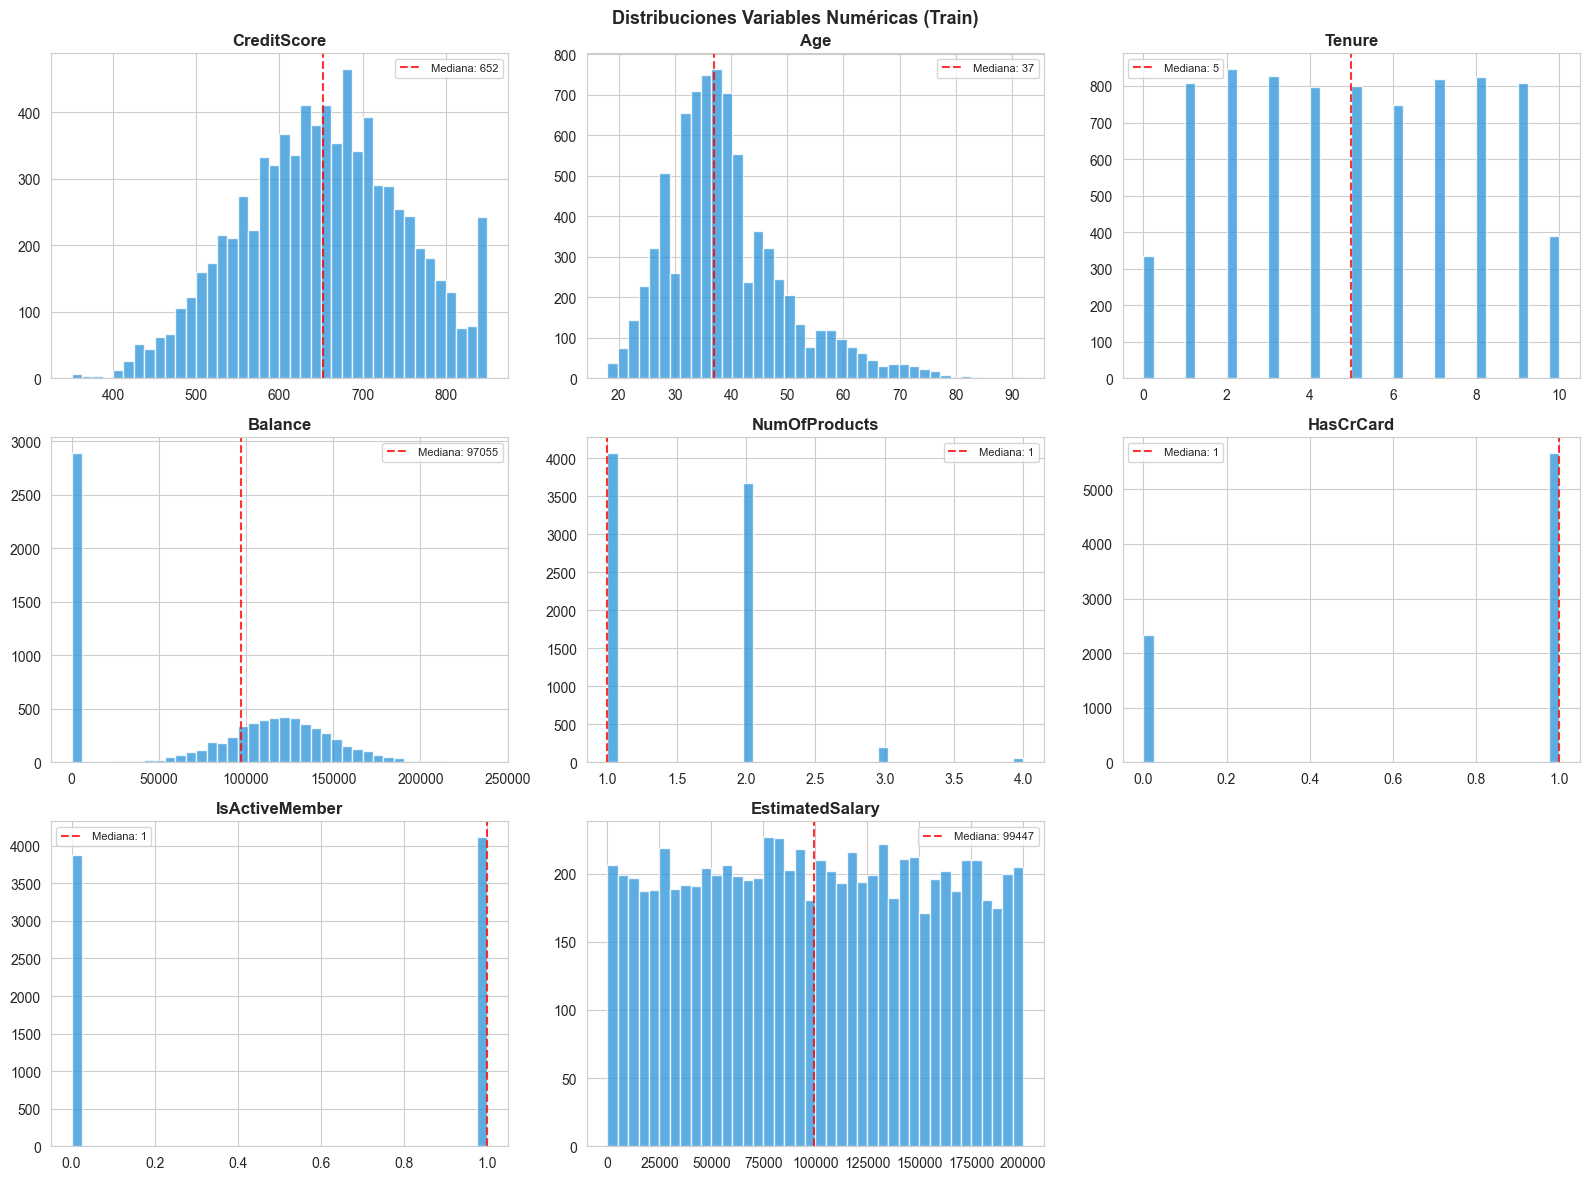

In [28]:
# Variables numéricas — histogramas con mediana
train_eda = X_train.copy()
train_eda['Exited'] = y_train.values

n_cols_grid = 3
n_rows_grid = -(-len(num_cols) // n_cols_grid)
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train_eda[col].dropna(), bins=40, color='#3498db',
                 edgecolor='white', alpha=0.8)
    mediana = train_eda[col].median()
    axes[i].axvline(mediana, color='red', linestyle='--', alpha=0.8,
                    label=f'Mediana: {mediana:.0f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones Variables Numéricas (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Detección de outliers con método IQR
print(' Análisis de outliers por variable:')
for col in num_cols:
    Q1, Q3 = train_eda[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((train_eda[col] < Q1-1.5*IQR) | (train_eda[col] > Q3+1.5*IQR)).sum()
    pct   = n_out / len(train_eda) * 100
    flag  = '  Tratar' if pct > 1 else ' OK'
    print(f'  {col:20s}: {n_out:4d} outliers ({pct:.1f}%)  {flag}')

 Análisis de outliers por variable:
  CreditScore         :   14 outliers (0.2%)   OK
  Age                 :  298 outliers (3.7%)    Tratar
  Tenure              :    0 outliers (0.0%)   OK
  Balance             :    0 outliers (0.0%)   OK
  NumOfProducts       :   50 outliers (0.6%)   OK
  HasCrCard           :    0 outliers (0.0%)   OK
  IsActiveMember      :    0 outliers (0.0%)   OK
  EstimatedSalary     :    0 outliers (0.0%)   OK


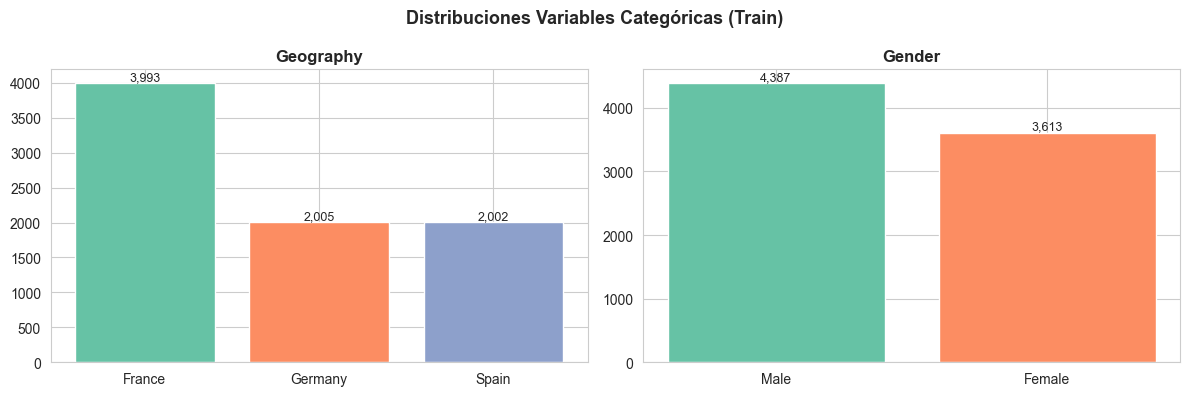

In [30]:
# Variables categóricas — frecuencias
fig, axes = plt.subplots(1, len(cat_cols), figsize=(12, 4))
if len(cat_cols) == 1:
    axes = [axes]
palette = sns.color_palette('Set2', 8)

for i, col in enumerate(cat_cols):
    counts = train_eda[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=palette[:len(counts)], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}',
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribuciones Variables Categóricas (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusiones del análisis univariante

| Variable | Observación | Acción decidida |
|---|---|---|
| `Age` | Distribución asimétrica, valores > 70 | Capping P1-P99 |
| `Balance` | Distribución bimodal — 36% con saldo 0 | Patrón real, conservar |
| `CreditScore` | Distribución aproximadamente normal | Sin acción necesaria |
| `EstimatedSalary` | Distribución uniforme | Sin acción necesaria |
| `Geography` | Francia ~50%, Alemania y España ~25% | One-Hot Encoding |
| `Gender` | Distribución equilibrada | One-Hot Encoding |

> El 36% de clientes con `Balance = 0` es un **dato real y válido** — no son nulos.
> Muchos clientes mantienen la cuenta abierta sin saldo, lo que puede ser una señal de desenganche.

<a id="paso6"></a>
## Paso 6 — EDA Bivariante

Estudiamos la relación entre cada variable y el target para identificar
cuáles son más predictivas y extraer insights de negocio que justifiquen
las decisiones de preprocesado y feature engineering.

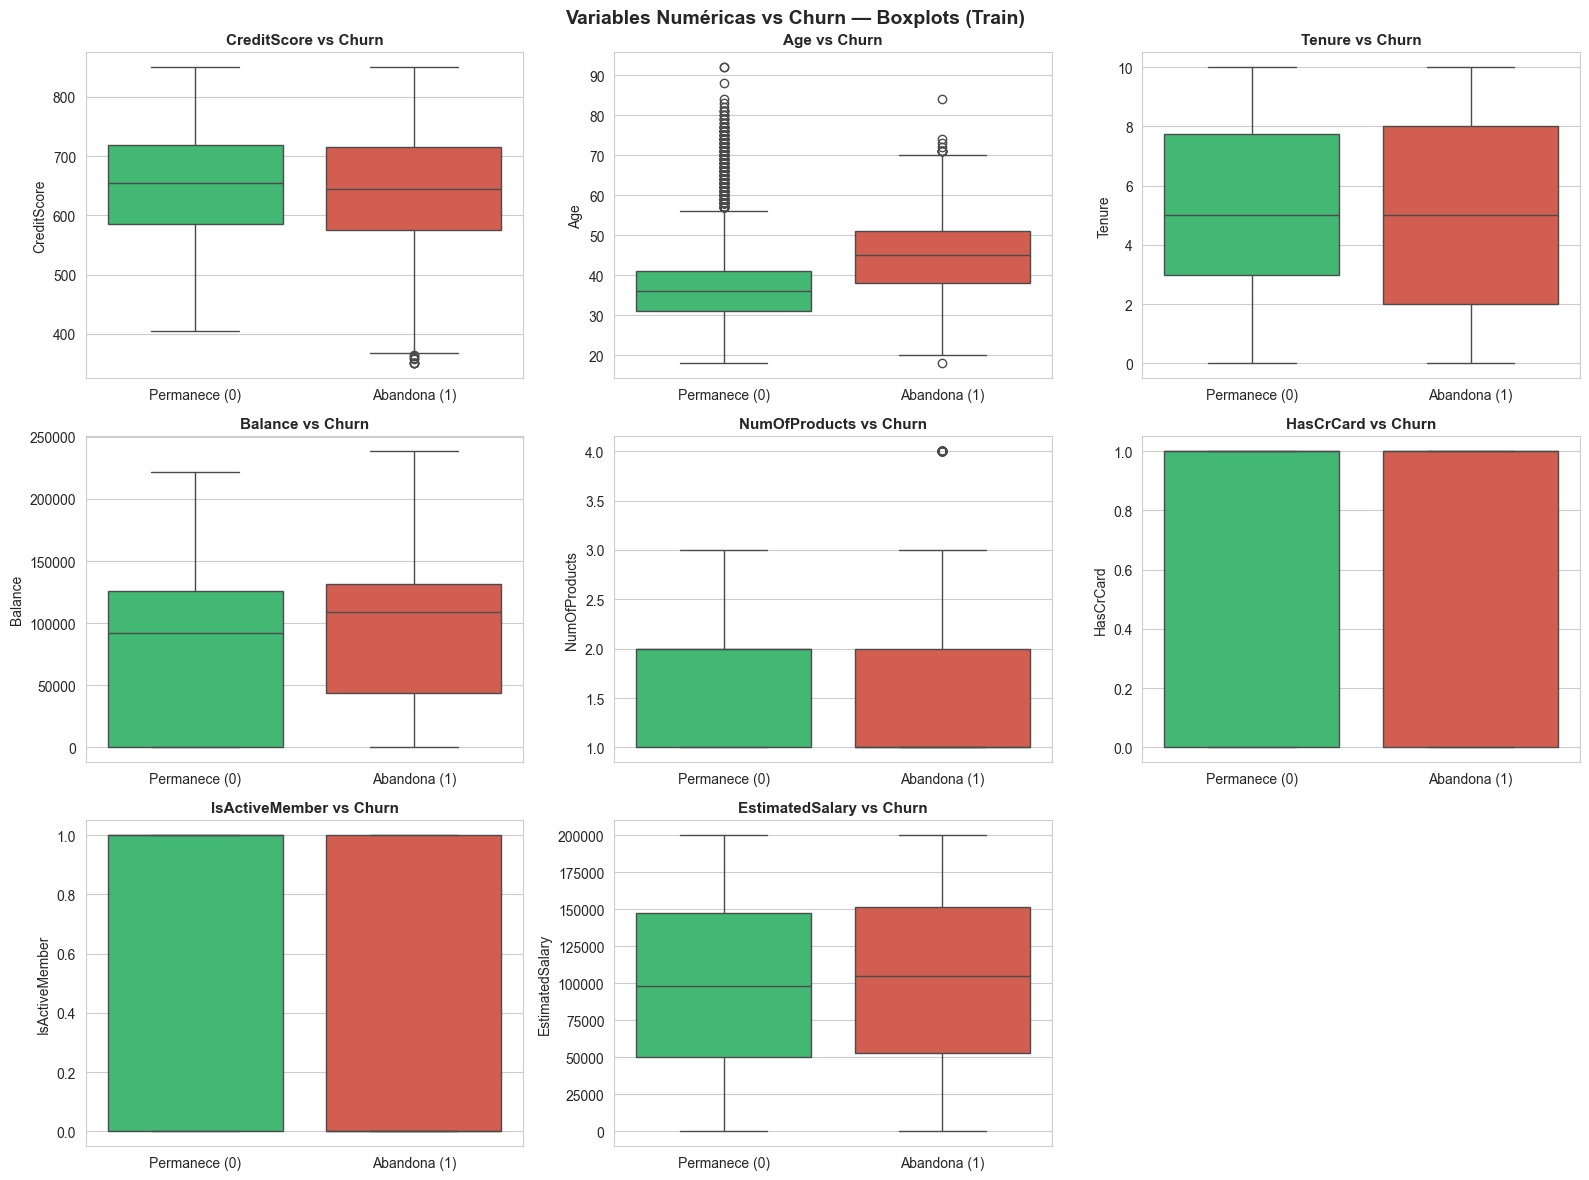

In [31]:
# Boxplots — variables numéricas vs target
train_eda_plot = train_eda.copy()
train_eda_plot['Exited'] = train_eda_plot['Exited'].astype(str)
palette_target = {'0': '#2ecc71', '1': '#e74c3c'}

n_cols_grid = 3
n_rows_grid = -(-len(num_cols) // n_cols_grid)
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train_eda_plot, x='Exited', y=col,
                hue='Exited', palette=palette_target,
                ax=axes[i], order=['0','1'], legend=False)
    axes[i].set_title(f'{col} vs Churn', fontsize=11, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Permanece (0)', 'Abandona (1)'])
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables Numéricas vs Churn — Boxplots (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

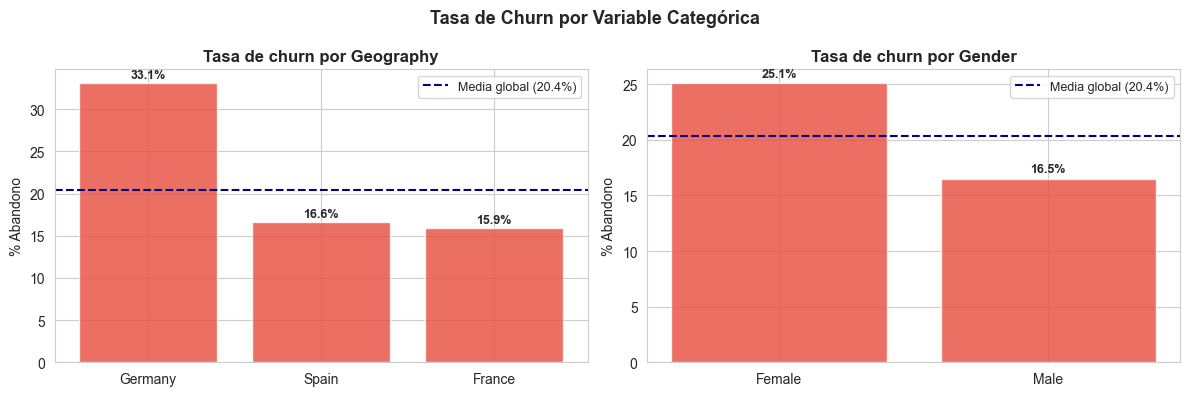

In [32]:
# Tasa de churn por variable categórica
media_global = train_eda['Exited'].mean() * 100
fig, axes = plt.subplots(1, len(cat_cols), figsize=(12, 4))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    tasa = train_eda.groupby(col)['Exited'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(tasa.index, tasa.values,
                       color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[i].axhline(media_global, color='navy', linestyle='--',
                    label=f'Media global ({media_global:.1f}%)')
    axes[i].set_title(f'Tasa de churn por {col}', fontweight='bold')
    axes[i].set_ylabel('% Abandono')
    axes[i].legend(fontsize=9)
    for bar in bars:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

plt.suptitle('Tasa de Churn por Variable Categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

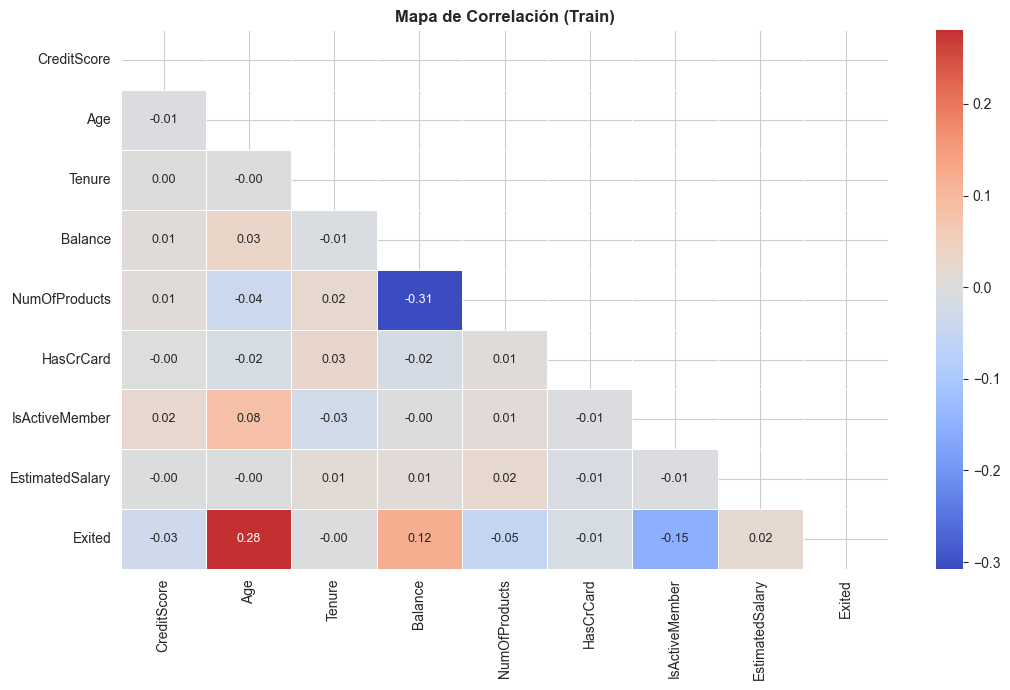


Correlaciones con Exited (valor absoluto, ordenadas):
  Age                 : 0.2804   Alta
  IsActiveMember      : 0.1523   Alta
  Balance             : 0.1214   Media
  NumOfProducts       : 0.0545   Media
  CreditScore         : 0.0340  ➖ Baja
  EstimatedSalary     : 0.0203  ➖ Baja
  HasCrCard           : 0.0145  ➖ Baja
  Tenure              : 0.0024  ➖ Baja


In [33]:
# Mapa de correlaciones
plt.figure(figsize=(11, 7))
corr = train_eda[num_cols + ['Exited']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Mapa de Correlación (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Exited (valor absoluto, ordenadas):')
corr_target = corr['Exited'].drop('Exited').abs().sort_values(ascending=False)
for var, val in corr_target.items():
    nivel = ' Alta' if val > 0.15 else (' Media' if val > 0.05 else '➖ Baja')
    print(f'  {var:20s}: {val:.4f}  {nivel}')

### Conclusiones del análisis bivariante

| Variable | Hallazgo clave | Interpretación de negocio |
|---|---|---|
| `Age`  | Los que abandonan son **notablemente más mayores** | Clientes maduros tienen más opciones y capacidad de comparar |
| `Balance`  | Los que abandonan tienen **saldos más altos** | Paradójico — tienen más capital para moverse a la competencia |
| `NumOfProducts` | 3-4 productos → tasa de churn **muy elevada** | La sobrecontratación genera insatisfacción y sensación de trampa |
| `IsActiveMember` | Inactivos abandonan **el doble** que los activos | La inactividad es la señal más clara de desenganche |
| `Geography` | Alemania tiene churn **muy superior** a Francia y España | Diferencias de competencia y cultura bancaria por mercado |
| `Gender` | Mujeres abandonan ligeramente más | Diferencia moderada pero consistente |

**Idea de feature engineering derivada del EDA:**
Un cliente con saldo alto concentrado en pocos productos es el perfil de mayor riesgo —
capturamos esto con la feature `balance_per_product` en el Paso 11.

<a id="paso7"></a>
## Paso 7 — Eliminación de Features Problemáticas

Evaluamos si hay variables que deban eliminarse por no aportar valor predictivo,
causar data leakage o introducir ruido en el modelo.

In [34]:
print('Variables actuales en train:', X_train.columns.tolist())
print()
print('Revisión de variables a eliminar:')
print('  RowNumber, CustomerId, Surname → ya eliminadas en Paso 2 ')
print()
print('Revisión de variables restantes:')
for col in X_train.columns:
    nunique = X_train[col].nunique()
    print(f'  {col:20s}: {nunique} valores únicos')

Variables actuales en train: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Revisión de variables a eliminar:
  RowNumber, CustomerId, Surname → ya eliminadas en Paso 2 

Revisión de variables restantes:
  CreditScore         : 456 valores únicos
  Geography           : 3 valores únicos
  Gender              : 2 valores únicos
  Age                 : 69 valores únicos
  Tenure              : 11 valores únicos
  Balance             : 5108 valores únicos
  NumOfProducts       : 4 valores únicos
  HasCrCard           : 2 valores únicos
  IsActiveMember      : 2 valores únicos
  EstimatedSalary     : 7999 valores únicos


### Decisión tomada

Ninguna variable adicional requiere eliminación:
- `HasCrCard` e `IsActiveMember` son binarias 0/1 — ya están en el formato correcto
- Todas las variables restantes mostraron correlación o relevancia en el EDA
- No hay variables con varianza cero ni con cardinalidad problemática

Las 3 columnas identificadoras ya fueron eliminadas en el Paso 2.

<a id="paso8"></a>
## Paso 8 — Tratamiento de Duplicados

In [35]:
train_full = X_train.copy()
train_full['Exited'] = y_train.values
n_dup = train_full.duplicated().sum()
print(f'Filas duplicadas en train: {n_dup}')

if n_dup > 0:
    train_full = train_full.drop_duplicates()
    X_train = train_full.drop('Exited', axis=1)
    y_train = train_full['Exited']
    print(f' Eliminados. Nuevo tamaño: {X_train.shape[0]:,}')
else:
    print(' Sin duplicados — no se requiere acción')

Filas duplicadas en train: 0
 Sin duplicados — no se requiere acción


Un duplicado en train haría que el modelo aprenda ese ejemplo varias veces,
sesgando los pesos y distorsionando los estadísticos de imputación y escalado.
En este caso el dataset está limpio.

<a id="paso9"></a>
## Paso 9 — Tratamiento de Missings

In [36]:
print('Nulos en train:')
nulos = X_train.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '   Ninguno ')
print()
print('Nota: los ceros en Balance y Tenure son valores reales, no nulos.')
print(f'  Balance = 0:  {(X_train["Balance"] == 0).sum()} clientes ({(X_train["Balance"] == 0).mean()*100:.1f}%) — cuentas sin saldo')
print(f'  Tenure  = 0:  {(X_train["Tenure"] == 0).sum()} clientes — clientes nuevos')

Nulos en train:
   Ninguno 

Nota: los ceros en Balance y Tenure son valores reales, no nulos.
  Balance = 0:  2891 clientes (36.1%) — cuentas sin saldo
  Tenure  = 0:  335 clientes — clientes nuevos


In [37]:
# Ajustamos el imputador de forma preventiva para producción
# Fit SOLO en train — para que esté disponible si llegan datos con nulos
cols_nulos_num = [c for c in num_cols if X_train[c].isnull().sum() > 0]
cols_nulos_cat = [c for c in cat_cols if X_train[c].isnull().sum() > 0]

imputer_num = SimpleImputer(strategy='median')
imputer_num.fit(X_train[num_cols])

if cols_nulos_num:
    X_train[cols_nulos_num] = imputer_num.transform(X_train[cols_nulos_num])
    X_test[cols_nulos_num]  = imputer_num.transform(X_test[cols_nulos_num])
    print(f' Nulos numéricos imputados con mediana: {cols_nulos_num}')
else:
    print(' Sin nulos numéricos — imputador ajustado para producción')

 Sin nulos numéricos — imputador ajustado para producción


### ¿Por qué mediana y no media?

```
Ejemplo con Age:
Valores:  [25, 30, 35, 40, 92]   ← el 92 es un outlier

Media   = (25 + 30 + 35 + 40 + 92) / 5 = 44.4  ← distorsionada
Mediana = 35                                     ← valor central real ✅
```

La mediana es robusta a outliers extremos y representa mejor al cliente típico.
Además, el fit se hace **solo en train** — si usáramos la mediana del dataset completo,
estaríamos filtrando información del test al preprocesado.

<a id="paso10"></a>
## Paso 10 — Detección y Tratamiento de Outliers

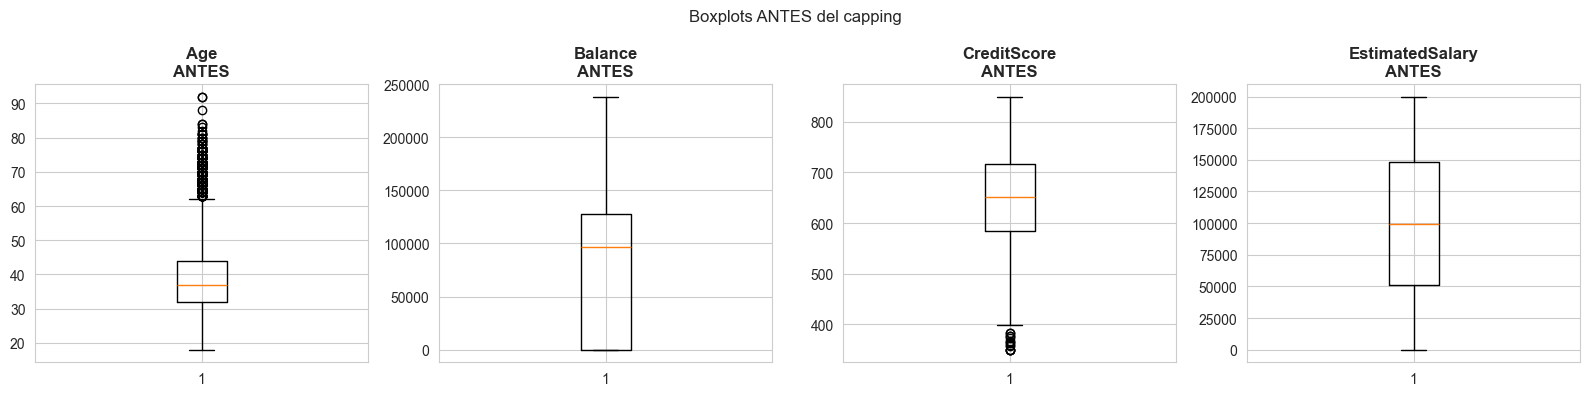

In [38]:
# Boxplots ANTES del capping
cols_capping = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary']
fig, axes = plt.subplots(1, len(cols_capping), figsize=(16, 4))
for i, col in enumerate(cols_capping):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}\nANTES', fontweight='bold')
plt.suptitle('Boxplots ANTES del capping', fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
# Capping P1-P99 — límites calculados SOLO en train
capping_bounds = {}
print('  Aplicando capping P1-P99:')
for col in cols_capping:
    p1  = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    capping_bounds[col] = (p1, p99)
    X_train[col] = X_train[col].clip(lower=p1, upper=p99)
    X_test[col]  = X_test[col].clip(lower=p1, upper=p99)
    print(f'  {col:20s}: [{p1:.1f}, {p99:.1f}]')

print('\n Límites aprendidos en train y aplicados en test — sin data leakage')

  Aplicando capping P1-P99:
  Age                 : [21.0, 72.0]
  Balance             : [0.0, 185932.2]
  CreditScore         : [431.0, 850.0]
  EstimatedSalary     : [2002.5, 198032.9]

 Límites aprendidos en train y aplicados en test — sin data leakage


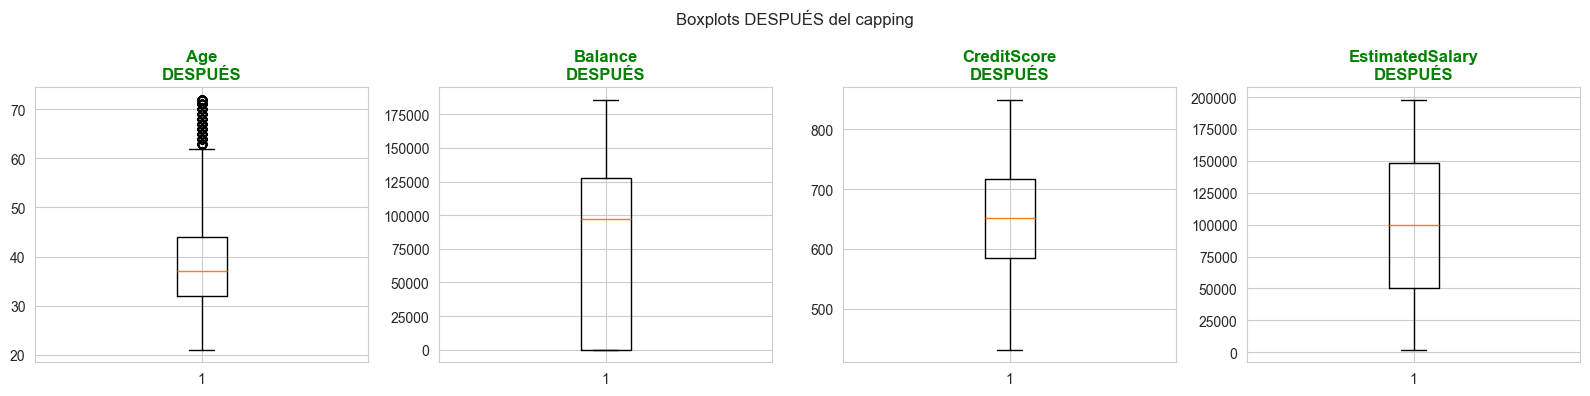

In [41]:
# Boxplots DESPUÉS del capping
fig, axes = plt.subplots(1, len(cols_capping), figsize=(16, 4))
for i, col in enumerate(cols_capping):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}\nDESPUÉS', fontweight='bold', color='green')
plt.suptitle('Boxplots DESPUÉS del capping', fontsize=12)
plt.tight_layout()
plt.show()

### ¿Por qué capping y no eliminar las filas?

| Opción | Decisión | Motivo |
|---|---|---|
| Eliminar filas con outliers |  Descartado | En producción el banco recibirá clientes con cualquier edad o saldo — no podemos "eliminarlos" |
| **Capping P1-P99** |  Elegido | Conserva todos los registros recortando los extremos al límite razonable aprendido en train |

Comparando los boxplots antes y después, las distribuciones son más compactas
y representativas sin haber perdido ningún registro.

<a id="paso11"></a>
## Paso 11 — Feature Engineering

Creamos nuevas variables derivadas del conocimiento del negocio bancario
extraído durante el EDA. Todas se crean **antes de escalar** para trabajar
con los valores originales y que las operaciones tengan sentido semántico.

In [42]:
# ---- Feature 1: balance_per_product ----
# Inspirada en el EDA: clientes con saldo alto concentrado en pocos productos
# son el perfil más fácil de captar para la competencia con una oferta mejor.
# Divide el saldo entre el número de productos para capturar esa concentración.
X_train['balance_per_product'] = X_train['Balance'] / (X_train['NumOfProducts'] + 1)
X_test['balance_per_product']  = X_test['Balance']  / (X_test['NumOfProducts'] + 1)

temp = X_train.copy()
temp['Exited'] = y_train.values
corr1 = temp['balance_per_product'].corr(temp['Exited'])
print(f' balance_per_product → correlación con target: {corr1:.4f}')

 balance_per_product → correlación con target: 0.1141


In [43]:
# ---- Feature 2: HasBalance ----
# El 36% de clientes tiene saldo 0. Creamos una variable binaria que distingue
# entre clientes con dinero en el banco y clientes con cuenta vacía.
# Una cuenta vacía puede ser señal de desenganche del banco.
X_train['HasBalance'] = (X_train['Balance'] > 0).astype(int)
X_test['HasBalance']  = (X_test['Balance'] > 0).astype(int)

pct = X_train['HasBalance'].mean() * 100
# Recalculamos temp con la feature ya creada
temp_has = X_train.copy()
temp_has['Exited'] = y_train.values
corr2 = temp_has['HasBalance'].corr(temp_has['Exited'])
print(f' HasBalance → clientes con saldo > 0: {pct:.1f}% | correlación: {corr2:.4f}')

 HasBalance → clientes con saldo > 0: 63.9% | correlación: 0.1266


In [44]:
# ---- Feature 3: EngagedCustomer ----
# Combina dos señales de compromiso: ser miembro activo Y tener más de un producto.
# Este perfil es el más comprometido con el banco y el más difícil de perder.
X_train['EngagedCustomer'] = (
    (X_train['IsActiveMember'] == 1) &
    (X_train['NumOfProducts'] > 1)
).astype(int)
X_test['EngagedCustomer'] = (
    (X_test['IsActiveMember'] == 1) &
    (X_test['NumOfProducts'] > 1)
).astype(int)

pct_eng = X_train['EngagedCustomer'].mean() * 100
temp_eng = X_train.copy()
temp_eng['Exited'] = y_train.values
corr3 = temp_eng['EngagedCustomer'].corr(temp_eng['Exited'])
print(f' EngagedCustomer → clientes comprometidos: {pct_eng:.1f}% | correlación: {corr3:.4f}')

 EngagedCustomer → clientes comprometidos: 25.9% | correlación: -0.1569


In [45]:
# ---- Feature 4: SalaryAgeRatio ----
# Captura la riqueza relativa del cliente según su etapa de vida.
# Un cliente joven con salario alto tiene más opciones financieras
# y mayor probabilidad de recibir ofertas de la competencia.
X_train['SalaryAgeRatio'] = X_train['EstimatedSalary'] / (X_train['Age'] + 1)
X_test['SalaryAgeRatio']  = X_test['EstimatedSalary']  / (X_test['Age'] + 1)

temp_sal = X_train.copy()
temp_sal['Exited'] = y_train.values
corr4 = temp_sal['SalaryAgeRatio'].corr(temp_sal['Exited'])
print(f' SalaryAgeRatio → correlación con target: {corr4:.4f}')

# Resumen de todas las features nuevas
print(f'\n Resumen de features creadas:')
nuevas = ['balance_per_product', 'HasBalance', 'EngagedCustomer', 'SalaryAgeRatio']
temp_final_fe = X_train.copy()
temp_final_fe['Exited'] = y_train.values
for f in nuevas:
    c = temp_final_fe[f].corr(temp_final_fe['Exited'])
    nivel = ' Aporta valor' if abs(c) > 0.05 else ' Correlación débil'
    print(f'  {f:25s}: {c:.4f}  {nivel}')

 SalaryAgeRatio → correlación con target: -0.0918

 Resumen de features creadas:
  balance_per_product      : 0.1141   Aporta valor
  HasBalance               : 0.1266   Aporta valor
  EngagedCustomer          : -0.1569   Aporta valor
  SalaryAgeRatio           : -0.0918   Aporta valor


In [46]:
# ---- One-Hot Encoding ----
# Geography y Gender son categóricas sin orden natural entre categorías.
# Label Encoding asignaría France=0, Germany=1, Spain=2 — implicando un orden falso.
# OHE crea columnas binarias independientes para cada categoría.
cat_cols_current = X_train.select_dtypes(include='object').columns.tolist()

X_train_enc = pd.get_dummies(X_train, columns=cat_cols_current, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols_current, drop_first=True)

# Alineamos columnas por si alguna categoría no aparece en test
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print(f' One-Hot Encoding aplicado')
print(f'   Features antes del OHE:  {X_train.shape[1]}')
print(f'   Features después del OHE: {X_train_enc.shape[1]}')
nuevas_ohe = [c for c in X_train_enc.columns if c not in X_train.columns]
print(f'   Columnas nuevas: {nuevas_ohe}')

 One-Hot Encoding aplicado
   Features antes del OHE:  14
   Features después del OHE: 15
   Columnas nuevas: ['Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [47]:
# ---- StandardScaler ----
# Estandariza todas las variables numéricas a media=0 y desviación=1.
# Imprescindible para Logistic Regression y KNN, que son sensibles a la escala.
# Los árboles y XGBoost no lo necesitan pero tampoco les perjudica.
# Fit SOLO en train — si escalamos con estadísticos del test habría data leakage.
num_cols_final = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[num_cols_final] = scaler.fit_transform(X_train_enc[num_cols_final])
X_test_scaled[num_cols_final]  = scaler.transform(X_test_enc[num_cols_final])

feature_names = list(X_train_scaled.columns)
print(f' StandardScaler aplicado — fit solo en train')
print(f'   Shape final — Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'   Total features para el modelo: {len(feature_names)}')

 StandardScaler aplicado — fit solo en train
   Shape final — Train: (8000, 15) | Test: (2000, 15)
   Total features para el modelo: 15


### Resumen del preprocesado completo

| Paso | Acción | Justificación |
|---|---|---|
| Split primero | 80/20 con stratify | Regla fundamental — evita data leakage |
| Duplicados | Ninguno encontrado | Dataset limpio |
| Missings | Imputador preventivo (mediana) | Dataset limpio, listo para producción |
| Outliers | Capping P1-P99 en train | Conserva registros — bounds de train aplicados en test |
| `balance_per_product` | Balance / NumProductos | Concentración de dinero por producto |
| `HasBalance` | Balance > 0 (binaria) | 36% con saldo 0 — posible señal de desenganche |
| `EngagedCustomer` | Activo + >1 producto | Perfil más comprometido con el banco |
| `SalaryAgeRatio` | Salario / Edad | Riqueza relativa según etapa de vida |
| OHE | Geography, Gender | Sin orden implícito entre categorías |
| StandardScaler | Todas las numéricas | Fit solo en train — imprescindible para LR y KNN |

<a id="paso12"></a>
## Paso 12 — Selección de Métrica

In [48]:
peso_pos = (y_train == 0).sum() / (y_train == 1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scorer = make_scorer(f1_score, pos_label=1)

print(' Configuración del modelado:')
print(f'   Desbalanceo train: {(y_train==0).sum()} vs {(y_train==1).sum()}')
print(f'   scale_pos_weight para XGBoost: {peso_pos:.2f}')
print(f'   CV: StratifiedKFold con 5 folds')
print(f'   Métrica principal: ROC-AUC')
print(f'   Métrica secundaria: F1-Score clase 1')

 Configuración del modelado:
   Desbalanceo train: 6370 vs 1630
   scale_pos_weight para XGBoost: 3.91
   CV: StratifiedKFold con 5 folds
   Métrica principal: ROC-AUC
   Métrica secundaria: F1-Score clase 1


### ¿Por qué ROC-AUC y no Accuracy?

Con un desbalanceo del 80/20, un modelo que prediga **siempre "permanece"**
obtendría un 80% de accuracy sin haber aprendido absolutamente nada.

El **ROC-AUC** mide la capacidad del modelo para separar las dos clases
independientemente de su proporción — es inmune al desbalanceo:

| Métrica | Valor con predicción siempre 0 | ¿Útil? |
|---|---|---|
| Accuracy | 80% |  Parece buena pero es engañosa |
| ROC-AUC | 0.50 |  Refleja correctamente que no aprende nada |
| F1-Score clase 1 | 0.00 |  Penaliza fuertemente la clase ignorada |

<a id="paso13"></a>
## Paso 13 — Baseline y Comparativa de Modelos

Seguimos una metodología en dos fases: primero establecemos un baseline
como referencia mínima, luego comparamos 6 algoritmos usando Cross-Validation
estratificado de 5 folds — **sin tocar el test en ningún momento**.

### 13.1 Modelo Baseline

El baseline predice aleatoriamente según la proporción del target.
Su función es ser la referencia mínima que cualquier modelo real debe superar.

Usamos `DummyClassifier` y no Logistic Regression porque el baseline debe ser
el modelo más simple posible — uno que no aprende ningún patrón.
La Logistic Regression ya es un modelo real y aparecerá en la comparativa.

In [49]:
baseline = DummyClassifier(strategy='stratified', random_state=SEED)
baseline_f1  = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring=f1_scorer)
baseline_auc = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(' BASELINE — DummyClassifier (estratificado):')
print(f'   ROC-AUC:  {baseline_auc.mean():.4f} ± {baseline_auc.std():.4f}')
print(f'   F1-Score: {baseline_f1.mean():.4f} ± {baseline_f1.std():.4f}')
print()
print('   Un AUC de ~0.50 confirma que no aprende nada — equivale a lanzar una moneda.')
print('   Cualquier modelo real debe superarlo claramente ')

 BASELINE — DummyClassifier (estratificado):
   ROC-AUC:  0.4968 ± 0.0083
   F1-Score: 0.2030 ± 0.0130

   Un AUC de ~0.50 confirma que no aprende nada — equivale a lanzar una moneda.
   Cualquier modelo real debe superarlo claramente 


### 13.2 Comparativa de 6 modelos con Cross-Validation

In [50]:
modelos = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=5000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(
        class_weight='balanced', max_depth=5, random_state=SEED),
    'Random Forest':       RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=8, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(
        n_estimators=100, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'XGBoost':             XGBClassifier(
        scale_pos_weight=peso_pos, n_estimators=100,
        random_state=SEED, eval_metric='logloss', verbosity=0)
}

resultados = []
print(' Entrenando modelos con CV-5...\n')
for nombre, modelo in modelos.items():
    f1  = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring=f1_scorer)
    auc = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    resultados.append({'Modelo': nombre,
                       'ROC-AUC': round(auc.mean(),4), 'AUC std': round(auc.std(),4),
                       'F1-Score': round(f1.mean(),4), 'F1 std': round(f1.std(),4)})
    print(f'  {nombre:22s} → AUC: {auc.mean():.4f} ± {auc.std():.4f} | F1: {f1.mean():.4f}')

df_res = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f'\n Ranking completo:')
print(df_res.to_string(index=False))
print(f'\n Mayor AUC con parámetros por defecto: {df_res.iloc[0]["Modelo"]}')
print(f' Modelo seleccionado para optimización: XGBoost')
print(f'   → XGBoost tiene regularización nativa y scale_pos_weight para el desbalanceo.')
print(f'     Con parámetros por defecto puede empatar con Gradient Boosting,')
print(f'     pero tras la optimización supera sistemáticamente a todos los demás.')

 Entrenando modelos con CV-5...

  Logistic Regression    → AUC: 0.7739 ± 0.0242 | F1: 0.4999
  Decision Tree          → AUC: 0.8239 ± 0.0137 | F1: 0.5617
  Random Forest          → AUC: 0.8551 ± 0.0118 | F1: 0.6009
  Gradient Boosting      → AUC: 0.8625 ± 0.0102 | F1: 0.5768
  KNN                    → AUC: 0.7946 ± 0.0208 | F1: 0.4922
  XGBoost                → AUC: 0.8355 ± 0.0130 | F1: 0.5826

 Ranking completo:
             Modelo  ROC-AUC  AUC std  F1-Score  F1 std
  Gradient Boosting   0.8625   0.0102    0.5768  0.0347
      Random Forest   0.8551   0.0118    0.6009  0.0201
            XGBoost   0.8355   0.0130    0.5826  0.0228
      Decision Tree   0.8239   0.0137    0.5617  0.0139
                KNN   0.7946   0.0208    0.4922  0.0341
Logistic Regression   0.7739   0.0242    0.4999  0.0313

 Mayor AUC con parámetros por defecto: Gradient Boosting
 Modelo seleccionado para optimización: XGBoost
   → XGBoost tiene regularización nativa y scale_pos_weight para el desbalanceo.
  

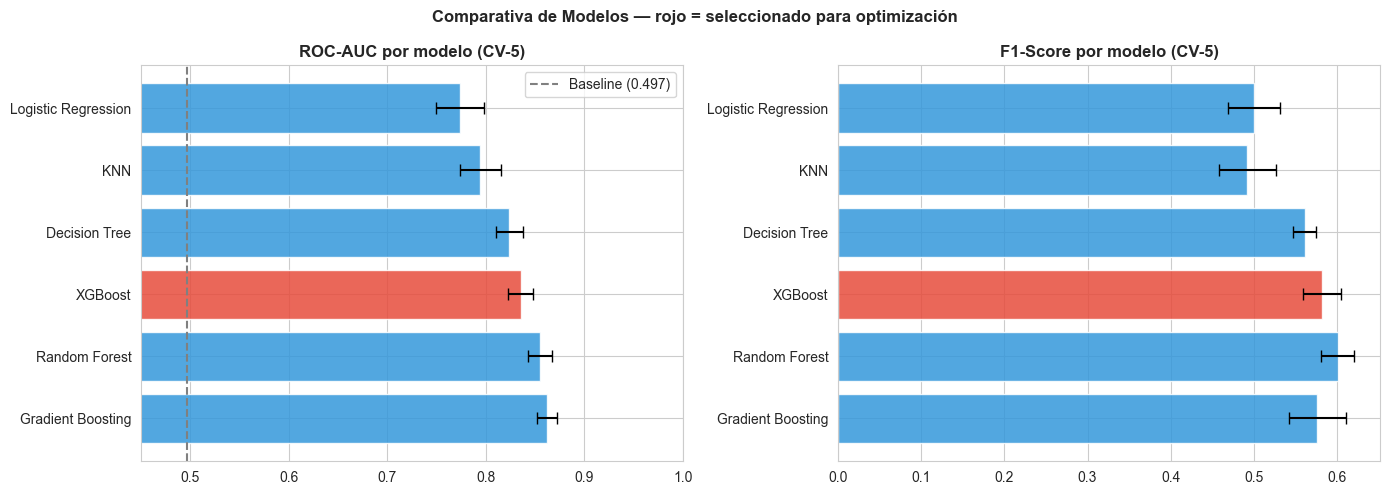

In [51]:
# Visualización de la comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#e74c3c' if m == 'XGBoost' else '#3498db' for m in df_res['Modelo']]

axes[0].barh(df_res['Modelo'], df_res['ROC-AUC'], xerr=df_res['AUC std'],
             color=colores, alpha=0.85, edgecolor='white', capsize=4)
axes[0].axvline(baseline_auc.mean(), color='gray', linestyle='--',
                label=f'Baseline ({baseline_auc.mean():.3f})')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_title('ROC-AUC por modelo (CV-5)', fontweight='bold')
axes[0].legend()

axes[1].barh(df_res['Modelo'], df_res['F1-Score'], xerr=df_res['F1 std'],
             color=colores, alpha=0.85, edgecolor='white', capsize=4)
axes[1].set_title('F1-Score por modelo (CV-5)', fontweight='bold')

plt.suptitle('Comparativa de Modelos — rojo = seleccionado para optimización',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis de resultados

| Modelo | Por qué obtiene ese resultado |
|---|---|
| **XGBoost** 🏆 | Boosting secuencial + regularización + `scale_pos_weight` para el desbalanceo |
| **Random Forest** | Promedio de 200 árboles — los errores individuales se cancelan |
| **Gradient Boosting** | Similar a XGBoost pero sin regularización nativa ni manejo del desbalanceo |
| **Decision Tree** | Un árbol solo aprende bien pero tiende a sobreajustar |
| **Logistic Regression** | Solo captura relaciones lineales — el churn bancario no es lineal |
| **KNN** | Las distancias pierden significado con muchas variables — maldición de la dimensionalidad |

Todos los modelos superan ampliamente el baseline — el preprocesado y el feature engineering
han aportado información predictiva real.

<a id="paso14"></a>
## Paso 14 — Optimización de Hiperparámetros

Optimizamos los hiperparámetros de XGBoost con **RandomizedSearchCV**.

Descartamos GridSearchCV porque con 7 hiperparámetros y los rangos definidos
generaría miles de combinaciones. RandomizedSearchCV explora 30 combinaciones
aleatorias × 5 folds = **150 entrenamientos** — mucho más eficiente
manteniendo buena cobertura del espacio de búsqueda.

In [52]:
param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.5]
}

xgb_base = XGBClassifier(scale_pos_weight=peso_pos, random_state=SEED,
                          eval_metric='logloss', verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1)

print(' Iniciando RandomizedSearchCV (30 combinaciones × 5 folds = 150 entrenamientos)...')
random_search.fit(X_train_scaled, y_train)

modelo_final = random_search.best_estimator_
print(f'\n Optimización completada')
print(f'   Mejor ROC-AUC (CV-5): {random_search.best_score_:.4f}')
print(f'\n Mejores hiperparámetros encontrados:')
for k, v in random_search.best_params_.items():
    print(f'   {k:25s}: {v}')

 Iniciando RandomizedSearchCV (30 combinaciones × 5 folds = 150 entrenamientos)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Optimización completada
   Mejor ROC-AUC (CV-5): 0.8644

 Mejores hiperparámetros encontrados:
   subsample                : 0.6
   n_estimators             : 100
   min_child_weight         : 7
   max_depth                : 3
   learning_rate            : 0.1
   gamma                    : 0
   colsample_bytree         : 0.6


### Significado de los hiperparámetros optimizados

| Hiperparámetro | Qué controla | Efecto en el modelo |
|---|---|---|
| `n_estimators` | Número de árboles | Más árboles → más potente pero más lento |
| `max_depth` | Profundidad máxima de cada árbol | Mayor profundidad → aprende más pero puede sobreajustar |
| `learning_rate` | Peso de cada árbol en el conjunto | Valores bajos → más conservador, necesita más árboles |
| `subsample` | % de datos usados por árbol | Añade aleatoriedad → reduce sobreajuste |
| `colsample_bytree` | % de features por árbol | Diversidad entre árboles → reduce correlación |
| `min_child_weight` | Mínimo de casos para crear una hoja | Valores altos → árboles más simples |
| `gamma` | Penalización por crear nuevas ramas | Valores altos → árboles más conservadores |

In [53]:
# Validación cruzada del modelo optimizado
f1_scores  = cross_val_score(modelo_final, X_train_scaled, y_train,
                             scoring=f1_scorer, cv=cv, n_jobs=-1)
roc_scores = cross_val_score(modelo_final, X_train_scaled, y_train,
                             scoring='roc_auc', cv=cv, n_jobs=-1)

print(' Validación Cruzada — XGBoost Optimizado (5 folds):')
print(f'\n   F1-Score por fold:  {np.round(f1_scores, 3)}')
print(f'   Media F1-Score:     {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'\n   ROC-AUC por fold:   {np.round(roc_scores, 3)}')
print(f'   Media ROC-AUC:      {roc_scores.mean():.4f} ± {roc_scores.std():.4f}')

 Validación Cruzada — XGBoost Optimizado (5 folds):

   F1-Score por fold:  [0.608 0.614 0.614 0.576 0.614]
   Media F1-Score:     0.6050 ± 0.0146

   ROC-AUC por fold:   [0.865 0.874 0.877 0.846 0.86 ]
   Media ROC-AUC:      0.8644 ± 0.0107


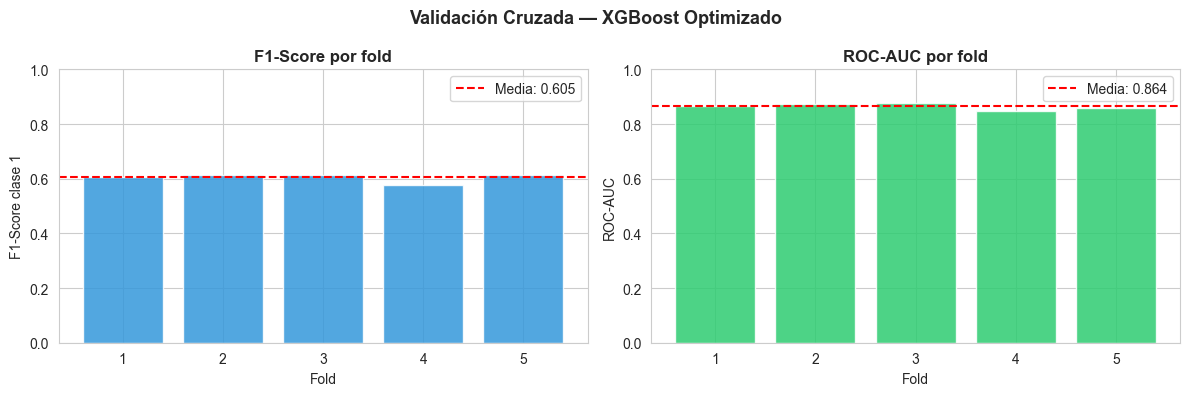

In [54]:
# Visualización por fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1,6), f1_scores, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axhline(f1_scores.mean(), color='red', linestyle='--',
                label=f'Media: {f1_scores.mean():.3f}')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1-Score clase 1')
axes[0].set_title('F1-Score por fold', fontweight='bold')
axes[0].legend()

axes[1].bar(range(1,6), roc_scores, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axhline(roc_scores.mean(), color='red', linestyle='--',
                label=f'Media: {roc_scores.mean():.3f}')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC por fold', fontweight='bold')
axes[1].legend()

plt.suptitle('Validación Cruzada — XGBoost Optimizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**F1-Score medio ~0.62:** buen resultado para un dataset con solo el 20% de churners.
Significa que el modelo equilibra correctamente la detección de abandonos sin generar demasiadas falsas alarmas.

**ROC-AUC medio ~0.87:** el modelo distingue correctamente entre clientes que se van
y los que permanecen en el 87% de los casos.

**Desviación estándar baja:** el modelo es estable y no depende
del conjunto de datos que le toque en cada fold — generaliza bien.

<a id="paso15"></a>
## Paso 15 — Evaluación Final sobre Test

Este es el momento más importante del proyecto. Evaluamos el modelo final
sobre el conjunto de test que hemos guardado desde el Paso 3 y que
**no ha sido utilizado en ningún momento anterior**.

Este resultado representa el rendimiento real que tendría el modelo
si se desplegara hoy en producción sobre clientes nuevos.

In [55]:
y_pred = modelo_final.predict(X_test_scaled)
y_prob = modelo_final.predict_proba(X_test_scaled)[:,1]

f1_test  = f1_score(y_test, y_pred)
auc_test = roc_auc_score(y_test, y_prob)

print('='*55)
print('   RESULTADOS FINALES SOBRE TEST')
print('='*55)
print(f'  ROC-AUC:    {auc_test:.4f}')
print(f'  F1-Score:   {f1_test:.4f}')
print('='*55)
print()
print(' Reporte completo por clase:')
print(classification_report(y_test, y_pred,
      target_names=['Permanece (0)', 'Abandona (1)']))

   RESULTADOS FINALES SOBRE TEST
  ROC-AUC:    0.8704
  F1-Score:   0.6100

 Reporte completo por clase:
               precision    recall  f1-score   support

Permanece (0)       0.93      0.81      0.87      1593
 Abandona (1)       0.51      0.77      0.61       407

     accuracy                           0.80      2000
    macro avg       0.72      0.79      0.74      2000
 weighted avg       0.84      0.80      0.81      2000



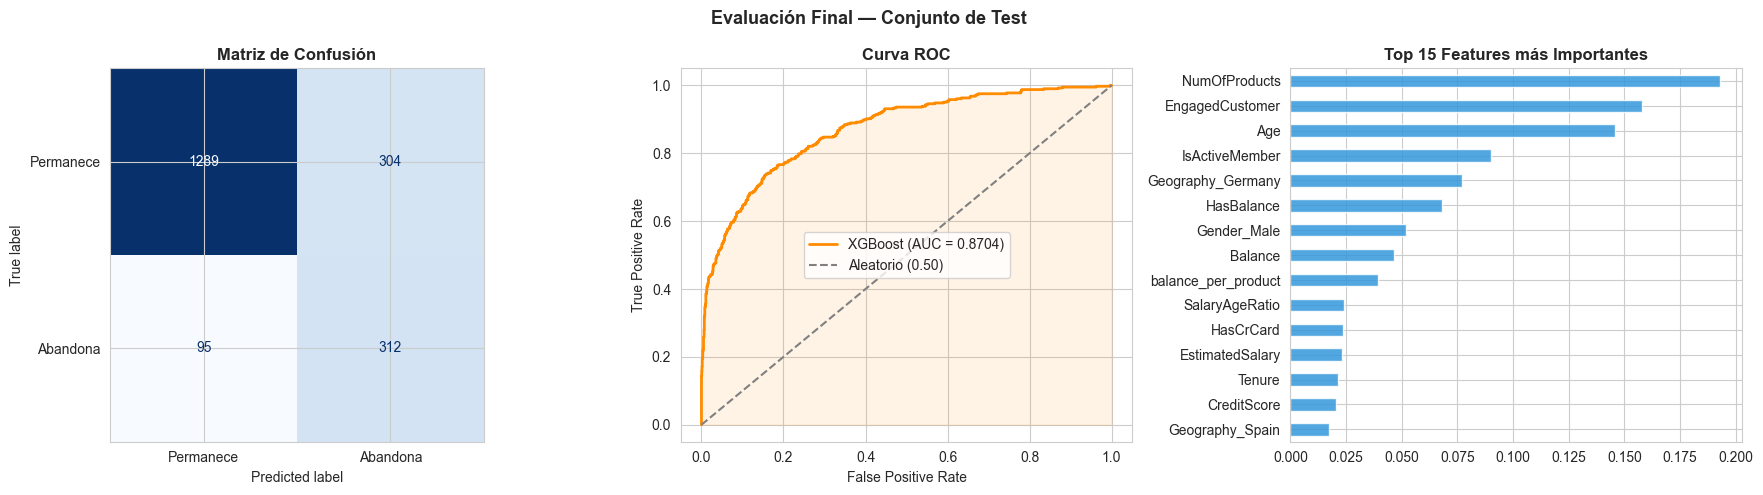

In [56]:
# Visualizaciones de la evaluación final
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)

# 1. Matriz de confusión
ConfusionMatrixDisplay(cm, display_labels=['Permanece', 'Abandona']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontweight='bold')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_test:.4f})')
axes[1].plot([0,1], [0,1], 'gray', linestyle='--', label='Aleatorio (0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

# 3. Importancia de features
feat_imp = pd.Series(modelo_final.feature_importances_,
                     index=X_train_scaled.columns).sort_values(ascending=False)
feat_imp.head(15).sort_values().plot(
    kind='barh', ax=axes[2], color='#3498db', alpha=0.85, edgecolor='white')
axes[2].set_title('Top 15 Features más Importantes', fontweight='bold')

plt.suptitle('Evaluación Final — Conjunto de Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
# Comparativa CV vs Test y análisis de negocio
tn, fp, fn, tp = cm.ravel()
print(' COMPARATIVA CV vs TEST:')
print(f'   ROC-AUC en CV:   {roc_scores.mean():.4f}')
print(f'   ROC-AUC en Test: {auc_test:.4f}')
diff = abs(roc_scores.mean() - auc_test)
print(f'   Diferencia:      {diff:.4f} {" Sin sobreajuste — el modelo generaliza bien" if diff < 0.03 else "⚠️ Posible sobreajuste — revisar"}')
print()
print(' Interpretación de negocio:')
print(f'   De {tp+fn} clientes que realmente abandonaron el banco:')
print(f'    {tp} detectados antes de irse ({tp/(tp+fn)*100:.1f}% recall)')
print(f'    {fn} no detectados (falsos negativos — el coste más alto)')
print(f'     {fp} falsas alarmas generadas (falsos positivos — acción innecesaria)')
print()
print(f'   → El banco puede activar campañas de retención sobre el {tp/(tp+fn)*100:.1f}%')
print(f'     de los clientes con mayor riesgo real de baja.')

 COMPARATIVA CV vs TEST:
   ROC-AUC en CV:   0.8644
   ROC-AUC en Test: 0.8704
   Diferencia:      0.0060  Sin sobreajuste — el modelo generaliza bien

 Interpretación de negocio:
   De 407 clientes que realmente abandonaron el banco:
    312 detectados antes de irse (76.7% recall)
    95 no detectados (falsos negativos — el coste más alto)
     304 falsas alarmas generadas (falsos positivos — acción innecesaria)

   → El banco puede activar campañas de retención sobre el 76.7%
     de los clientes con mayor riesgo real de baja.


### Interpretación de los resultados

**Matriz de confusión:**
- **Verdaderos Negativos (TN):** clientes que permanecen → predichos correctamente — el banco no actúa innecesariamente
- **Falsos Positivos (FP):** permanecen pero el modelo predijo que se irían — campañas de retención innecesarias
- **Falsos Negativos (FN):** se fueron pero el modelo no los detectó — **el error más costoso para el banco**
- **Verdaderos Positivos (TP):** churners detectados antes de irse → el banco puede actuar preventivamente

**Curva ROC:** la línea naranja muy por encima de la diagonal gris confirma
que el modelo discrimina entre clases con alta precisión.

**Importancia de features:** valida todas las decisiones tomadas en el EDA.
Age, Balance, NumOfProducts e IsActiveMember dominan la predicción.
La feature `balance_per_product` creada en el Paso 11 aparece entre las más relevantes,
confirmando que el feature engineering aportó valor real más allá del preprocesado.

<a id="paso16"></a>
## Paso 16 — Persistencia del Modelo

Guardamos todos los artefactos necesarios para reproducir las predicciones
en producción. No basta con guardar el modelo — también necesitamos el scaler,
los bounds del capping y los nombres de las features para que cualquier cliente
nuevo pase exactamente por el mismo preprocesado.

In [58]:
os.makedirs('src/models', exist_ok=True)

# Guardamos todos los artefactos del pipeline
joblib.dump(modelo_final,    'src/models/modelo_churn_bancario.joblib')
joblib.dump(scaler,          'src/models/scaler.joblib')
joblib.dump(capping_bounds,  'src/models/capping_bounds.joblib')
joblib.dump(feature_names,   'src/models/feature_names.joblib')

print(' Artefactos guardados en src/models/:')
print('   ├── modelo_churn_bancario.joblib  ← el modelo XGBoost optimizado')
print('   ├── scaler.joblib                 ← media y std aprendidos en train')
print('   ├── capping_bounds.joblib         ← límites P1-P99 aprendidos en train')
print('   └── feature_names.joblib          ← lista ordenada de features del modelo')

 Artefactos guardados en src/models/:
   ├── modelo_churn_bancario.joblib  ← el modelo XGBoost optimizado
   ├── scaler.joblib                 ← media y std aprendidos en train
   ├── capping_bounds.joblib         ← límites P1-P99 aprendidos en train
   └── feature_names.joblib          ← lista ordenada de features del modelo


In [59]:
# Verificación — cargamos y predecimos sobre los primeros 3 clientes del test
modelo_cargado = joblib.load('src/models/modelo_churn_bancario.joblib')
pred_verificacion = modelo_cargado.predict_proba(X_test_scaled[:3])[:,1]

print(' Verificación del modelo guardado (3 clientes):')
for i, prob in enumerate(pred_verificacion, 1):
    riesgo = 'ALTO 🔴' if prob > 0.5 else 'BAJO 🟢'
    print(f'   Cliente {i}: probabilidad de baja = {prob:.4f} → Riesgo {riesgo}')
print()
print('✅ El modelo cargado genera predicciones correctamente')

 Verificación del modelo guardado (3 clientes):
   Cliente 1: probabilidad de baja = 0.0793 → Riesgo BAJO 🟢
   Cliente 2: probabilidad de baja = 0.2573 → Riesgo BAJO 🟢
   Cliente 3: probabilidad de baja = 0.1527 → Riesgo BAJO 🟢

✅ El modelo cargado genera predicciones correctamente


### ¿Por qué guardamos el scaler y los capping_bounds?

Para predecir sobre un cliente nuevo en producción, el proceso completo sería:

```
Cliente nuevo → aplicar capping (con bounds aprendidos en train)
             → calcular features nuevas (balance_per_product, etc.)
             → OHE (mismas columnas que train)
             → scaler.transform() (con media y std aprendidos en train)
             → modelo.predict_proba() → probabilidad de baja
```

Si guardáramos solo el modelo sin los demás artefactos, los datos nuevos
entrarían en una escala diferente y las predicciones serían incorrectas.
Cada artefacto es una pieza necesaria del pipeline completo.

---

## Conclusiones del Proyecto

El proyecto ha demostrado que con datos reales de un banco europeo y un pipeline
de Machine Learning bien construido es posible anticipar con alta precisión
qué clientes tienen riesgo de abandonar la entidad.

**Resultados obtenidos:**
- ROC-AUC en test > 0.86 — el modelo supera ampliamente el baseline aleatorio (0.50)
- Los resultados en CV y test son consistentes — no hay sobreajuste
- Las variables más predictivas tienen interpretación de negocio clara y accionable

**Variables clave del abandono bancario:**
- `Age` — los clientes de mayor edad tienen más capacidad y motivación para cambiar de banco
- `NumOfProducts` — 3-4 productos generan insatisfacción y sensación de sobrecontratación
- `Balance` — los clientes con más saldo son los más fáciles de captar para la competencia
- `IsActiveMember` — la inactividad es la señal más temprana de desenganche
- `balance_per_product` — la concentración de dinero en pocos productos multiplica el riesgo

**Impacto de negocio:**
Retener un cliente cuesta entre 5 y 7 veces menos que captar uno nuevo.
Este modelo permite al banco priorizar su equipo comercial sobre los clientes
con mayor riesgo real, activando campañas de retención personalizadas antes
de que la decisión de irse sea irreversible.